We are Developing a personalized content recommendation engine that suggests content (e.g., posts, articles, videos) based on user behavior and interaction history.

1. Import Libraries

In [1]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

# Data handling libraries
from datetime import datetime
import pandas as pd
import numpy as np
import json
import os

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Alternative: Use sparse similarity matrix because of memory constraints, you can use it fully if you have enough memory.
from scipy.sparse import lil_matrix

# For displaying outputs in Jupyter Notebook
from IPython.display import clear_output


# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


2. Load Dataset

In [2]:
# ============================================================
# STEP 2: LOAD MIND DATASET
# ============================================================

# Define column names for news dataset
news_columns = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities"
]

# Define column names for behaviors dataset
behavior_columns = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions"
]

# Load news dataset
news_df = pd.read_csv(
    "Dataset/news.tsv",
    sep="\t",
    names=news_columns
)

# Load behaviors dataset
behaviors_df = pd.read_csv(
    "Dataset/behaviors.tsv",
    sep="\t",
    names=behavior_columns
)

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


3. Dataset Exploration

In [3]:
# ============================================================
# STEP 3: DATASET EXPLORATION
# ============================================================

# Display first 5 rows of news dataset
print("News Dataset")
display(news_df.head())

# Display first 5 rows of behavior dataset
print("Behavior Dataset")
display(behaviors_df.head())

# Dataset shapes
print("News Shape:", news_df.shape)
print("Behaviors Shape:", behaviors_df.shape)

News Dataset


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


Behavior Dataset


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


News Shape: (51282, 8)
Behaviors Shape: (156965, 5)


In [4]:
# ============================================================
# STEP 3: CHECK MISSING VALUES AND DUPLICATES
# ============================================================

# Missing values in news dataset
print("Missing Values in News Dataset")
print(news_df.isnull().sum())

print("\n")

# Missing values in behavior dataset
print("Missing Values in Behaviors Dataset")
print(behaviors_df.isnull().sum())


#duplicate values in news dataset
print("Duplicate Values in News Dataset")
print(news_df.duplicated().sum())

print("\n")

#duplicate values in behavior dataset
print("Duplicate Values in Behaviors Dataset")
print(behaviors_df.duplicated().sum())

Missing Values in News Dataset
news_id                 0
category                0
subcategory             0
title                   0
abstract             2666
url                     0
title_entities          3
abstract_entities       4
dtype: int64


Missing Values in Behaviors Dataset
impression_id       0
user_id             0
time                0
history          3238
impressions         0
dtype: int64
Duplicate Values in News Dataset
0


Duplicate Values in Behaviors Dataset
0


4. Data Cleaning

In [5]:
# ============================================================
# STEP 4: CLEAN NEWS DATASET
# ============================================================

def clean_news_data(news_df):
    """
    Clean and preprocess news dataset.
    """

    # Remove rows with missing title or abstract
    news_df = news_df.dropna(subset=['title', 'abstract'])

    # Remove duplicate news
    news_df = news_df.drop_duplicates(subset=['news_id'])

    # Convert text to lowercase
    news_df['title'] = news_df['title'].str.lower()
    news_df['abstract'] = news_df['abstract'].str.lower()

    # Combine title and abstract
    news_df['combined_text'] = (
        news_df['title'] + " " + news_df['abstract']
    )

    return news_df


# Apply preprocessing
news_df = clean_news_data(news_df)

print("News Dataset Cleaned Successfully")

News Dataset Cleaned Successfully


5. Behavior Processing

In [6]:
# ============================================================
# STEP 5: PROCESS USER BEHAVIORS
# ============================================================

# Define interaction weights globally
INTERACTION_WEIGHTS = {
    'click': 2,      # Click shows interest
    'view': 1,       # Viewed but didn't click
}

def process_behaviors(behaviors_df):
    """
    Convert impressions into structured interactions.
    NOW captures BOTH clicks AND views with proper weights.
    """
    
    interactions = []
    
    print("🔄 Processing user behaviors with proper scoring...")
    
    # Loop through each row
    for _, row in behaviors_df.iterrows():
        
        # Skip missing impressions
        if pd.isna(row['impressions']):
            continue
        
        user_id = row['user_id']
        timestamp = row['time']  # Keep original timestamp for real decay
        
        # Split impressions
        impressions = str(row['impressions']).split()
        
        # Process each impression
        for item in impressions:
            
            try:
                news_id, flag = item.split('-')
                
                # Determine interaction type and weight based on flag
                if flag == '1':
                    interaction_type = 'click'
                    weight = INTERACTION_WEIGHTS['click']
                elif flag == '0':
                    interaction_type = 'view'
                    weight = INTERACTION_WEIGHTS['view']
                else:
                    continue
                
                interactions.append({
                    'user_id': user_id,
                    'news_id': news_id,
                    'interaction_type': interaction_type,
                    'weight': weight,
                    'timestamp': timestamp  # Keep original timestamp
                })
                
            except:
                continue
    
    interactions_df = pd.DataFrame(interactions)
    
    print(f"✓ Created {len(interactions_df)} interaction records")
    print(f"  - Clicks: {len(interactions_df[interactions_df['interaction_type']=='click'])}")
    print(f"  - Views: {len(interactions_df[interactions_df['interaction_type']=='view'])}")
    
    return interactions_df

# Create interactions dataframe
interactions_df = process_behaviors(behaviors_df)

# Display interactions
display(interactions_df.head())

print("Interactions Processed Successfully")

🔄 Processing user behaviors with proper scoring...
✓ Created 5843444 interaction records
  - Clicks: 236344
  - Views: 5607100


,user_id,news_id,interaction_type,weight,timestamp
0,U13740,N55689,click,2,11/11/2019 9:05:58 AM
1,U13740,N35729,view,1,11/11/2019 9:05:58 AM
2,U91836,N20678,view,1,11/12/2019 6:11:30 PM
3,U91836,N39317,view,1,11/12/2019 6:11:30 PM
4,U91836,N58114,view,1,11/12/2019 6:11:30 PM


Interactions Processed Successfully


6. Time Decay Scoring

In [7]:
# ============================================================
# STEP 6: TIME DECAY SCORING
# ============================================================


def apply_time_decay(interactions_df, half_life_days=30):
    """
    Apply time decay to interaction scores using REAL timestamps.
    Formula: final_score = weight * (0.5)^(days_ago / half_life)
    """
    
    print("⏰ Applying REAL time decay using actual timestamps...")
    
    # Convert timestamp to datetime (MIND format: MM/DD/YYYY HH:MM:SS AM/PM)
    interactions_df['timestamp'] = pd.to_datetime(interactions_df['timestamp'], format='%m/%d/%Y %I:%M:%S %p')
    
    # Get latest date in dataset
    latest_date = interactions_df['timestamp'].max()
    print(f"  Latest date in dataset: {latest_date}")
    
    # Calculate days difference from latest date
    interactions_df['days_ago'] = (latest_date - interactions_df['timestamp']).dt.days
    
    # Apply decay formula: weight * (0.5)^(days_ago / half_life)
    decay_factor = np.power(0.5, interactions_df['days_ago'] / half_life_days)
    
    # Calculate final score
    interactions_df['final_score'] = interactions_df['weight'] * decay_factor
    
    print(f"✓ Time decay applied (half-life: {half_life_days} days)")
    print(f"  Oldest interaction: {interactions_df['days_ago'].max()} days ago")
    print(f"  Newest interaction: {interactions_df['days_ago'].min()} days ago")
    print(f"  Score range: {interactions_df['final_score'].min():.3f} to {interactions_df['final_score'].max():.3f}")
    
    return interactions_df

# Apply time decay
interactions_df = apply_time_decay(interactions_df)

display(interactions_df.head())

print("Time Decay Applied Successfully")

⏰ Applying REAL time decay using actual timestamps...
  Latest date in dataset: 2019-11-14 23:59:13
✓ Time decay applied (half-life: 30 days)
  Oldest interaction: 5 days ago
  Newest interaction: 0 days ago
  Score range: 0.891 to 2.000


,user_id,news_id,interaction_type,weight,timestamp,days_ago,final_score
0,U13740,N55689,click,2,2019-11-11 09:05:58,3,1.866066
1,U13740,N35729,view,1,2019-11-11 09:05:58,3,0.933033
2,U91836,N20678,view,1,2019-11-12 18:11:30,2,0.954842
3,U91836,N39317,view,1,2019-11-12 18:11:30,2,0.954842
4,U91836,N58114,view,1,2019-11-12 18:11:30,2,0.954842


Time Decay Applied Successfully


7. User Preference Profiling

In [8]:
# ============================================================
# STEP 7: CREATE USER PREFERENCE PROFILES
# ============================================================

USER_PROFILES_FILE = 'user_profiles.json'

def save_user_profiles_to_file(user_profiles_dict):
    """Save user profiles to JSON file"""
    try:
        with open(USER_PROFILES_FILE, 'w') as f:
            json.dump(user_profiles_dict, f, indent=2, default=str)
        print(f"💾 User profiles saved to {USER_PROFILES_FILE}")
    except Exception as e:
        print(f"⚠️ Could not save profiles: {e}")

def load_user_profiles_from_file():
    """Load user profiles from JSON file"""
    if os.path.exists(USER_PROFILES_FILE):
        try:
            with open(USER_PROFILES_FILE, 'r') as f:
                profiles = json.load(f)
            print(f"📂 Loaded {len(profiles)} user profiles from {USER_PROFILES_FILE}")
            return profiles
        except:
            print("⚠️ Could not load saved profiles")
    return {}

def create_user_profiles(interactions_df, news_df):
    """
    Create user preference profiles with time decay.
    """
    
    print("📊 Creating user profiles with time decay...")
    
    # Merge interaction data with news data
    merged_df = pd.merge(
        interactions_df,
        news_df[['news_id', 'category']],
        on='news_id',
        how='left'
    )
    
    # Fill missing categories
    merged_df['category'] = merged_df['category'].fillna('General')
    
    # Calculate category preference scores
    user_profiles_list = []
    
    # Group by user and category, sum final scores
    grouped = merged_df.groupby(['user_id', 'category'])['final_score'].sum().reset_index()
    
    # Also calculate total engagement per user
    user_totals = merged_df.groupby('user_id')['final_score'].sum().reset_index()
    user_totals.columns = ['user_id', 'total_engagement']
    
    # Calculate seen content per user
    user_seen = merged_df.groupby('user_id')['news_id'].apply(list).reset_index()
    user_seen.columns = ['user_id', 'seen_content']
    
    # Merge all together
    user_profiles_list = grouped.merge(user_totals, on='user_id', how='left')
    user_profiles_list = user_profiles_list.merge(user_seen, on='user_id', how='left')
    
    # Normalize scores per user (divide by total engagement)
    user_profiles_list['normalized_score'] = user_profiles_list['final_score'] / user_profiles_list['total_engagement']
    
    # Sort scores
    user_profiles_list = user_profiles_list.sort_values(
        by='normalized_score',
        ascending=False
    )
    
    # Convert to dictionary format for easier access
    user_profiles_dict = {}
    for user_id in user_profiles_list['user_id'].unique():
        user_data = user_profiles_list[user_profiles_list['user_id'] == user_id]
        preferences = dict(zip(user_data['category'], user_data['normalized_score']))
        
        user_profiles_dict[user_id] = {
            'preferences': preferences,
            'seen_content': user_data['seen_content'].iloc[0] if len(user_data) > 0 else [],
            'total_engagement': float(user_data['total_engagement'].iloc[0]) if len(user_data) > 0 else 0,
            'top_categories': sorted(preferences.items(), key=lambda x: x[1], reverse=True)[:3]
        }
    
    # Load existing profiles and merge (preserve across sessions)
    existing_profiles = load_user_profiles_from_file()
    for user_id, profile in user_profiles_dict.items():
        existing_profiles[user_id] = profile
    
    # Save merged profiles
    save_user_profiles_to_file(existing_profiles)
    
    print(f"✓ Created profiles for {len(user_profiles_dict)} users")
    
    return user_profiles_dict

# Create user profiles
user_profiles_dict = create_user_profiles(
    interactions_df,
    news_df
)

# Display profiles
print("\n📊 Sample User Profiles:")
sample_users = list(user_profiles_dict.keys())[:3]
for user in sample_users:
    print(f"\nUser {user}:")
    print(f"  Top categories: {user_profiles_dict[user]['top_categories']}")
    print(f"  Total engagement: {user_profiles_dict[user]['total_engagement']:.2f}")

print("\nUser Profiles Created Successfully")

📊 Creating user profiles with time decay...
📂 Loaded 50000 user profiles from user_profiles.json
💾 User profiles saved to user_profiles.json
✓ Created profiles for 50000 users

📊 Sample User Profiles:

User U71443:
  Top categories: [('news', 1.0)]
  Total engagement: 4.56

User U66165:
  Top categories: [('news', 1.0)]
  Total engagement: 2.93

User U93677:
  Top categories: [('finance', 1.0)]
  Total engagement: 2.86

User Profiles Created Successfully


8. TF-IDF Content Representation

In [9]:
# ============================================================
# STEP 8: TF-IDF CONTENT REPRESENTATION
# ============================================================

def create_tfidf_matrix(news_df):
    """
    Create TF-IDF feature matrix.
    """

    # Initialize TF-IDF vectorizer
    tfidf = TfidfVectorizer(
        stop_words='english',
        max_features=5000
    )

    # Transform text into vectors
    tfidf_matrix = tfidf.fit_transform(
        news_df['combined_text']
    )

    return tfidf, tfidf_matrix


# Create TF-IDF matrix
tfidf_vectorizer, tfidf_matrix = create_tfidf_matrix(news_df)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

print("TF-IDF Matrix Created Successfully")

TF-IDF Matrix Shape: (48616, 5000)
TF-IDF Matrix Created Successfully


9. Cosine Similarity

In [10]:
# ============================================================
# STEP 9: COSINE SIMILARITY (MEMORY-EFFICIENT VERSION)
# ============================================================

def compute_similarity_chunked(tfidf_matrix, chunk_size=1000):
    """
    Compute cosine similarity matrix in chunks to avoid memory issues.
    
    Args:
        tfidf_matrix: Sparse matrix of shape (n_samples, n_features)
        chunk_size: Number of rows to process at once
    
    Returns:
        similarity_matrix: Dense matrix of shape (n_samples, n_samples)
    """
    
    n_samples = tfidf_matrix.shape[0]
    print(f"📊 Computing similarity for {n_samples} items in chunks...")
    
    # Initialize empty matrix (will be filled incrementally)
    # Note: This still requires memory, but we can also return a sparse matrix
    
    # Create empty sparse matrix in LIL format (good for incremental building)
    similarity_sparse = lil_matrix((n_samples, n_samples), dtype=np.float32)
    
    for i in range(0, n_samples, chunk_size):
        end_idx = min(i + chunk_size, n_samples)
        print(f"  Processing rows {i} to {end_idx}...")
        
        # Compute similarity for current chunk
        chunk_similarity = cosine_similarity(tfidf_matrix[i:end_idx], tfidf_matrix)
        
        # Store in sparse matrix (keep only top-k similarities to save memory)
        # For each row, keep only top 100 similarities
        for row_in_chunk, row_global in enumerate(range(i, end_idx)):
            # Get similarities for this row
            row_similarities = chunk_similarity[row_in_chunk]
            
            # Keep only top 100 similarities (excluding self)
            # This reduces memory dramatically
            top_indices = np.argsort(row_similarities)[-101:-1]  # Top 100 excluding self
            top_values = row_similarities[top_indices]
            
            for idx, val in zip(top_indices, top_values):
                if val > 0.01:  # Only keep similarities above threshold
                    similarity_sparse[row_global, idx] = val
        
        # Clear chunk from memory
        del chunk_similarity
    
    print(f"✓ Created sparse similarity matrix with {similarity_sparse.nnz} non-zero entries")
    
    return similarity_sparse

def get_similar_items(similarity_sparse, item_idx, top_n=10):
    """
    Get top N similar items for a given item using sparse matrix.
    """
    # Get row as dense array
    row = similarity_sparse[item_idx].toarray().flatten()
    
    # Get top indices (excluding self)
    top_indices = np.argsort(row)[-top_n-1:-1][::-1]
    top_scores = row[top_indices]
    
    return list(zip(top_indices, top_scores))

# Compute similarity matrix with chunking
print("🔄 Computing cosine similarity with memory optimization...")
similarity_sparse = compute_similarity_chunked(tfidf_matrix, chunk_size=500)

print(f"Similarity Matrix Shape: {similarity_sparse.shape}")
print(f"Memory usage: {similarity_sparse.data.nbytes / 1024**3:.2f} GB")
print("Cosine Similarity Computed Successfully (Sparse Format)")

🔄 Computing cosine similarity with memory optimization...
📊 Computing similarity for 48616 items in chunks...
  Processing rows 0 to 500...
  Processing rows 500 to 1000...
  Processing rows 1000 to 1500...
  Processing rows 1500 to 2000...
  Processing rows 2000 to 2500...
  Processing rows 2500 to 3000...
  Processing rows 3000 to 3500...
  Processing rows 3500 to 4000...
  Processing rows 4000 to 4500...
  Processing rows 4500 to 5000...
  Processing rows 5000 to 5500...
  Processing rows 5500 to 6000...
  Processing rows 6000 to 6500...
  Processing rows 6500 to 7000...
  Processing rows 7000 to 7500...
  Processing rows 7500 to 8000...
  Processing rows 8000 to 8500...
  Processing rows 8500 to 9000...
  Processing rows 9000 to 9500...
  Processing rows 9500 to 10000...
  Processing rows 10000 to 10500...
  Processing rows 10500 to 11000...
  Processing rows 11000 to 11500...
  Processing rows 11500 to 12000...
  Processing rows 12000 to 12500...
  Processing rows 12500 to 13000..

10. Visualization


📊 Visualizing preferences for user: U71443


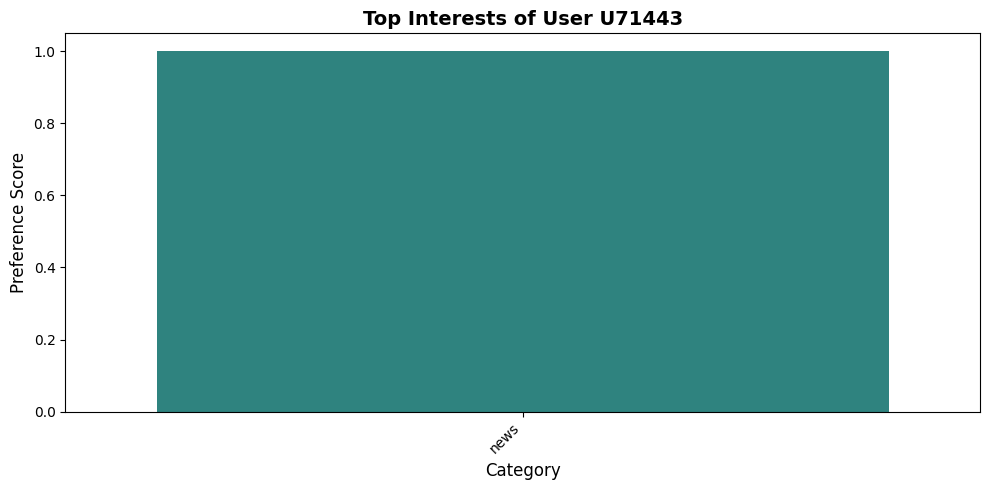

In [11]:
# ============================================================
# STEP 10: VISUALIZE USER INTERESTS
# ============================================================

def visualize_user_interests(user_profiles_dict, user_id):
    """
    Visualize user category preferences from dictionary.
    """
    
    if user_id not in user_profiles_dict:
        print(f"User {user_id} not found")
        return
    
    # Get user preferences from dictionary
    preferences = user_profiles_dict[user_id].get('preferences', {})
    
    if not preferences:
        print(f"No preferences found for user {user_id}")
        return
    
    # Convert to DataFrame for easier plotting
    user_df = pd.DataFrame({
        'category': list(preferences.keys()),
        'final_score': list(preferences.values())
    })
    
    # Sort top categories
    user_df = user_df.sort_values(
        by='final_score',
        ascending=False
    ).head(10)
    
    # Create chart
    plt.figure(figsize=(10, 5))
    
    sns.barplot(
        data=user_df,
        x='category',
        y='final_score',
        palette='viridis'
    )
    
    # Chart labels
    plt.title(f"Top Interests of User {user_id}", fontsize=14, fontweight='bold')
    plt.xlabel("Category", fontsize=12)
    plt.ylabel("Preference Score", fontsize=12)
    
    # Rotate category names
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

# Example visualization (use a sample user)
if len(user_profiles_dict) > 0:
    sample_user = list(user_profiles_dict.keys())[0]
    print(f"\n📊 Visualizing preferences for user: {sample_user}")
    visualize_user_interests(user_profiles_dict, sample_user)
else:
    print("No user profiles available for visualization")

11. Recommendation Engine

In [13]:
# ============================================================
# STEP 11: CONTENT RECOMMENDATION ENGINE
# ============================================================

def recommend_news(
    user_id,
    interactions_df,
    news_df,
    similarity_matrix,
    top_n=5,
    user_profiles_dict=None
):
    """
    Generate personalized recommendations with proper scoring.
    """
    
    print(f"🎯 Generating recommendations for user: {user_id}")
    
    # Get clicked news by user
    clicked_news = interactions_df[
        (interactions_df['user_id'] == user_id) &
        (interactions_df['interaction_type'] == 'click')
    ]['news_id'].tolist()
    
    # If no clicks, recommend popular content
    if len(clicked_news) == 0:
        print("  No click history. Using popular content.")
        return get_popular_recommendations(news_df, interactions_df, top_n)
    
    # Get user preferences from profiles if available
    user_prefs = {}
    if user_profiles_dict and user_id in user_profiles_dict:
        user_prefs = user_profiles_dict[user_id].get('preferences', {})
    
    # Empty recommendation scores
    recommendation_scores = {}
    
    # Loop through clicked news
    for news_id in clicked_news:
        
        # Skip missing news ids
        if news_id not in news_df['news_id'].values:
            continue
        
        # Get news index
        news_index = news_df[
            news_df['news_id'] == news_id
        ].index[0]
        
        # Get similarity scores
        similar_scores = list(
            enumerate(similarity_matrix[news_index])
        )
        
        # Sort by similarity
        similar_scores = sorted(
            similar_scores,
            key=lambda x: x[1],
            reverse=True
        )
        
        # Add scores
        for idx, score in similar_scores[1:20]:
            
            recommended_news_id = news_df.iloc[idx]['news_id']
            
            # Skip already clicked news
            if recommended_news_id in clicked_news:
                continue
            
            # Get category for diversity bonus
            rec_category = news_df.iloc[idx]['category']
            
            # Apply category preference boost if available
            category_boost = user_prefs.get(rec_category, 0.5)
            
            # Accumulate scores with category boost
            final_score = score * (0.7 + 0.3 * category_boost)
            
            recommendation_scores[recommended_news_id] = (
                recommendation_scores.get(
                    recommended_news_id,
                    0
                ) + final_score
            )
    
    # Sort recommendations
    sorted_recommendations = sorted(
        recommendation_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )
    
    # Top recommendations
    top_recommendations = sorted_recommendations[:top_n]
    
    # Convert to dataframe
    recommendation_list = []
    
    for news_id, score in top_recommendations:
        
        article = news_df[
            news_df['news_id'] == news_id
        ].iloc[0]
        
        recommendation_list.append({
            'news_id': news_id,
            'title': article['title'],
            'category': article['category'],
            'recommendation_score': score
        })
    
    print(f"  Generated {len(recommendation_list)} recommendations")
    
    return pd.DataFrame(recommendation_list)

def get_popular_recommendations(news_df, interactions_df, top_n=5):
    """Get globally popular content for cold-start users"""
    
    # Count interactions per news
    popular = interactions_df.groupby('news_id').size().reset_index(name='popularity')
    popular = popular.sort_values('popularity', ascending=False).head(top_n)
    
    # Merge with news info
    result = popular.merge(news_df[['news_id', 'title', 'category']], on='news_id', how='left')
    result['recommendation_score'] = result['popularity'] / result['popularity'].max()
    
    return result[['news_id', 'title', 'category', 'recommendation_score']]

# Example recommendation
if len(interactions_df) > 0:
    sample_user = interactions_df['user_id'].iloc[0]
    print(f"\n📊 Testing recommendations for user: {sample_user}")

    recommendations_df = recommend_news(
        sample_user,
        interactions_df,
        news_df,
        similarity_sparse,
        user_profiles_dict=user_profiles_dict
    )

    display(recommendations_df)

print("Recommendations Generated Successfully")


📊 Testing recommendations for user: U13740
🎯 Generating recommendations for user: U13740
  Generated 0 recommendations


""


Recommendations Generated Successfully


12. Trending news Recommendation

In [14]:
# ============================================================
# STEP 12: TRENDING NEWS RECOMMENDATION
# ============================================================

def get_trending_news(
    interactions_df,
    news_df,
    top_n=5
):
    """
    Get globally trending news based on click counts.
    """
    
    # Count clicks per news (using interaction_type instead of clicked column)
    trending = (
        interactions_df[
            interactions_df['interaction_type'] == 'click'
        ]
        .groupby('news_id')
        .size()
        .reset_index(name='click_count')
    )
    
    # Sort by popularity
    trending = trending.sort_values(
        by='click_count',
        ascending=False
    )
    
    # Top trending news
    trending = trending.head(top_n)
    
    # Merge with news titles
    trending = pd.merge(
        trending,
        news_df[['news_id', 'title', 'category']],
        on='news_id',
        how='left'
    )
    
    return trending

# Display trending news
trending_news_df = get_trending_news(
    interactions_df,
    news_df
)

display(trending_news_df)

print("Trending News Generated Successfully")

,news_id,click_count,title,category
0,N55689,4316,"charles rogers, former michigan state football...",sports
1,N35729,3346,porsche launches into second story of new jers...,news
2,N33619,3246,college gymnast dies following training accide...,news
3,N53585,2835,"rip taylor's cause of death revealed, memorial...",tv
4,N63970,2578,dean foods files for bankruptcy,finance


Trending News Generated Successfully


13. Hybrid Recommendation System

In [17]:
# ============================================================
# STEP 13: HYBRID RECOMMENDATION SYSTEM
# ============================================================


def hybrid_recommendation(
    personalized_df,
    trending_df,
    personalized_weight=0.7,
    trending_weight=0.3
):
    """
    Combine personalized and trending news.
    """

    # Create copy
    personalized_df = personalized_df.copy()
    trending_df = trending_df.copy()

    # Add weighted scores
    personalized_df['final_hybrid_score'] = (
        personalized_df['recommendation_score'] *
        personalized_weight
    )

    trending_df['final_hybrid_score'] = (
        trending_df['click_count'] *
        trending_weight
    )

    # Standardize columns
    trending_df = trending_df.rename(
        columns={
            'click_count': 'recommendation_score'
        }
    )

    # Combine datasets
    combined_df = pd.concat([
        personalized_df[
            ['news_id', 'title', 'category',
             'final_hybrid_score']
        ],
        trending_df[
            ['news_id', 'title', 'category',
             'final_hybrid_score']
        ]
    ])

    # Remove duplicates
    combined_df = combined_df.drop_duplicates(
        subset='news_id'
    )

    # Sort scores
    combined_df = combined_df.sort_values(
        by='final_hybrid_score',
        ascending=False
    )

    return combined_df.head(10)


# Generate hybrid recommendations
# Fallback if personalized recommendations are empty or missing the score column
if recommendations_df.empty or 'recommendation_score' not in recommendations_df.columns:
    recommendations_df = get_popular_recommendations(news_df, interactions_df, top_n=10)

hybrid_df = hybrid_recommendation(
    recommendations_df,
    trending_news_df
)

display(hybrid_df)

print("Hybrid Recommendations Generated Successfully")

,news_id,title,category,final_hybrid_score
1,N35729,porsche launches into second story of new jers...,news,1003.800000
2,N33619,college gymnast dies following training accide...,news,973.800000
3,N53585,"rip taylor's cause of death revealed, memorial...",tv,850.500000
4,N63970,dean foods files for bankruptcy,finance,773.400000
0,N47061,105 black friday deals you can start shopping ...,lifestyle,0.700000
1,N51048,NaN,NaN,0.584686
2,N26262,celebrity plastic surgery transformations,entertainment,0.580553
3,N50872,50 amazing gifts for every type of person and ...,lifestyle,0.568277
4,N55689,"charles rogers, former michigan state football...",sports,0.556518
5,N38779,'one in a million' deer captured on camera in ...,news,0.550015


Hybrid Recommendations Generated Successfully


14. Real-Time Recommendation Update

In [18]:
# ============================================================
# STEP 14: REAL-TIME RECOMMENDATION UPDATE
# ============================================================

def add_new_interaction(
    interactions_df,
    user_id,
    news_id,
    interaction_type='click',
    user_profiles_dict=None,
    news_df=None
):
    """
    Add new user interaction dynamically with proper timing.
    """
    
    print(f"🔄 Adding new {interaction_type} for user {user_id}")
    
    # Get weight for interaction type
    weight = INTERACTION_WEIGHTS.get(interaction_type, 1.0)
    
    # Get current timestamp
    current_time = datetime.now()
    
    # Calculate days ago (0 for current)
    days_ago = 0
    
    # Apply decay (no decay for new interactions)
    decay_factor = np.power(0.5, days_ago / 30)
    final_score = weight * decay_factor
    
    # Create new interaction row
    new_row = pd.DataFrame({
        'user_id': [user_id],
        'news_id': [news_id],
        'interaction_type': [interaction_type],
        'weight': [weight],
        'timestamp': [current_time],
        'days_ago': [days_ago],
        'final_score': [final_score]
    })
    
    # Append interaction
    updated_df = pd.concat(
        [interactions_df, new_row],
        ignore_index=True
    )
    
    # Update user profile if available
    if user_profiles_dict is not None and news_df is not None:
        # Get news category
        news_category = news_df[news_df['news_id'] == news_id]['category'].values
        category = news_category[0] if len(news_category) > 0 else 'General'
        
        # Update or create user profile
        if user_id in user_profiles_dict:
            # Update preferences
            current_prefs = user_profiles_dict[user_id]['preferences']
            current_prefs[category] = current_prefs.get(category, 0) + final_score
            
            # Re-normalize
            total = sum(current_prefs.values())
            if total > 0:
                current_prefs = {k: v/total for k, v in current_prefs.items()}
            
            # Update profile
            user_profiles_dict[user_id]['preferences'] = current_prefs
            user_profiles_dict[user_id]['seen_content'].append(news_id)
            user_profiles_dict[user_id]['total_engagement'] += final_score
            user_profiles_dict[user_id]['top_categories'] = sorted(
                current_prefs.items(), key=lambda x: x[1], reverse=True
            )[:3]
            
            print(f"  ✓ Updated profile for {user_id}")
        else:
            # Create new user profile
            user_profiles_dict[user_id] = {
                'preferences': {category: 1.0},
                'seen_content': [news_id],
                'total_engagement': final_score,
                'top_categories': [(category, 1.0)]
            }
            print(f"  ✓ Created new profile for {user_id}")
        
        # Save updated profiles
        save_user_profiles_to_file(user_profiles_dict)
    
    print(f"  ✓ Interaction added with weight {weight}, final score {final_score:.3f}")
    
    return updated_df, user_profiles_dict

# Example real-time interaction
sample_user = interactions_df['user_id'].iloc[0]
sample_news = news_df['news_id'].iloc[10]

print(f"\n📝 Testing real-time update for user: {sample_user}")
print(f"   News: {sample_news}")

# Update interactions
interactions_df, user_profiles_dict = add_new_interaction(
    interactions_df,
    sample_user,
    sample_news,
    interaction_type='click',
    user_profiles_dict=user_profiles_dict,
    news_df=news_df
)

print("\nReal-Time Interaction Added Successfully")


📝 Testing real-time update for user: U13740
   News: N9721
🔄 Adding new click for user U13740
  ✓ Updated profile for U13740
💾 User profiles saved to user_profiles.json
  ✓ Interaction added with weight 2, final score 2.000

Real-Time Interaction Added Successfully


15. Generate Updated Recommendations

In [21]:
# ============================================================
# STEP 15: UPDATED RECOMMENDATIONS
# ============================================================


# Generate updated recommendations
updated_recommendations = recommend_news(
    sample_user,
    interactions_df,
    news_df,
    similarity_sparse,
    user_profiles_dict=user_profiles_dict
)

# Display recommendations
display(updated_recommendations)

print("Updated Recommendations Generated")

🎯 Generating recommendations for user: U13740
  Generated 0 recommendations


""


Updated Recommendations Generated


16. Category-Based Filtering

In [22]:
# ============================================================
# STEP 16: CATEGORY-BASED FILTERING
# ============================================================


def filter_by_category(
    recommendations_df,
    category_name
):
    """
    Filter recommendations by category.
    """

    filtered_df = recommendations_df[
        recommendations_df['category'].str.lower()
        == category_name.lower()
    ]

    return filtered_df


# Example category filtering
ai_recommendations = filter_by_category(
    hybrid_df,
    "sports"
)

display(ai_recommendations)

print("Category Filtering Applied Successfully")

,news_id,title,category,final_hybrid_score
4,N55689,"charles rogers, former michigan state football...",sports,0.556518


Category Filtering Applied Successfully


17. Recommendation Visualization

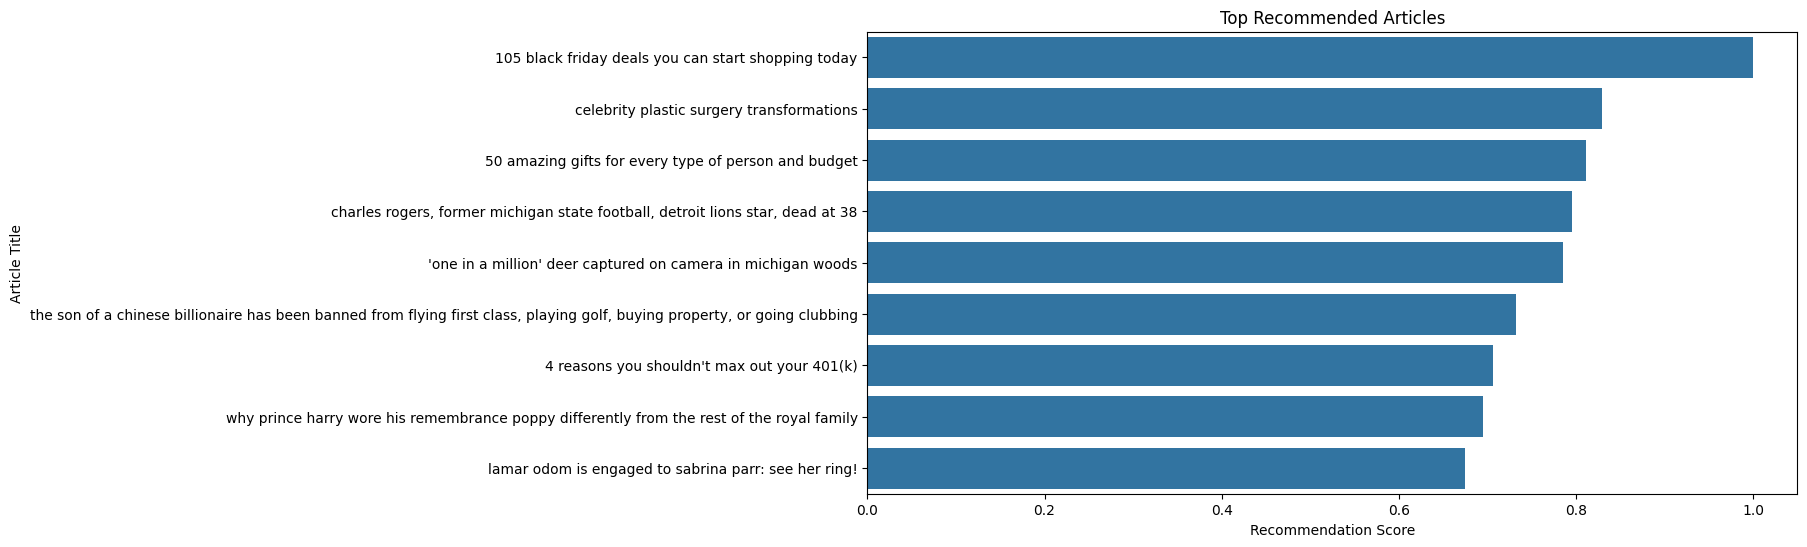

Recommendation Visualization Created


In [23]:
# ============================================================
# STEP 17: RECOMMENDATION VISUALIZATION
# ============================================================


def visualize_recommendations(recommendations_df):
    """
    Visualize top recommendation scores.
    """

    # Create figure
    plt.figure(figsize=(12, 6))

    # Plot recommendations
    sns.barplot(
        data=recommendations_df,
        x='recommendation_score',
        y='title'
    )

    # Chart labels
    plt.title("Top Recommended Articles")
    plt.xlabel("Recommendation Score")
    plt.ylabel("Article Title")

    plt.show()


# Visualize recommendations
visualize_recommendations(recommendations_df)

print("Recommendation Visualization Created")

18. Cold Start Problem Handling

In [24]:
# ============================================================
# STEP 18: COLD START PROBLEM HANDLING
# ============================================================


def cold_start_recommendation(
    trending_df,
    top_n=5
):
    """
    Recommend trending news to new users.
    """

    return trending_df.head(top_n)


# Example cold start recommendation
new_user_recommendations = cold_start_recommendation(
    trending_news_df
)

display(new_user_recommendations)

print("Cold Start Recommendations Generated")

,news_id,click_count,title,category
0,N55689,4316,"charles rogers, former michigan state football...",sports
1,N35729,3346,porsche launches into second story of new jers...,news
2,N33619,3246,college gymnast dies following training accide...,news
3,N53585,2835,"rip taylor's cause of death revealed, memorial...",tv
4,N63970,2578,dean foods files for bankruptcy,finance


Cold Start Recommendations Generated


19. Export Recommendations

In [25]:
# ============================================================
# STEP 19: EXPORT RECOMMENDATIONS
# ============================================================


def export_recommendations(
    recommendations_df,
    file_name="recommendations.csv"
):
    """
    Export recommendations to CSV.
    """

    recommendations_df.to_csv(
        file_name,
        index=False
    )

    print(f"Recommendations saved to {file_name}")


# Export recommendations
export_recommendations(hybrid_df)

Recommendations saved to recommendations.csv


20. Top news Category

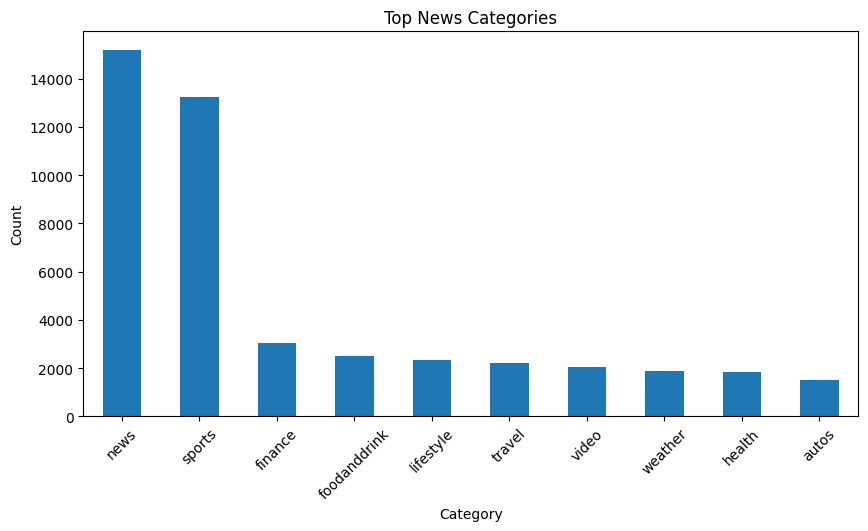

In [26]:
# ============================================================
# STEP 20. TOP NEWS CATEGORIES
# ============================================================

# Count categories
category_counts = news_df['category'].value_counts().head(10)

# Plot chart
plt.figure(figsize=(10, 5))

category_counts.plot(kind='bar')

plt.title("Top News Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

21. Simple CLI Interface

In [29]:
# ============================================================
# CELL 21: CLI INTERFACE WITH PROPER SCORING
# ============================================================

def get_recommendations_wrapper(user_id, n=5, category_filter=None):
    """
    Wrapper function for getting recommendations with optional category filter
    """
    # Get recommendations
    recs_df = recommend_news(
        user_id,
        interactions_df,
        news_df,
        similarity_sparse,
        top_n=n*2,  # Get extra for filtering
        user_profiles_dict=user_profiles_dict
    )
    
    # Apply category filter if specified
    if category_filter and len(recs_df) > 0:
        recs_df = recs_df[recs_df['category'].str.lower() == category_filter.lower()]
    
    # Return top n
    return recs_df.head(n)

def add_new_interaction_wrapper(user_id, news_id, interaction_type):
    """
    Wrapper for adding new interactions and updating profiles
    """
    global interactions_df, user_profiles_dict
    
    interactions_df, user_profiles_dict = add_new_interaction(
        interactions_df,
        user_id,
        news_id,
        interaction_type,
        user_profiles_dict,
        news_df
    )
    
    return user_profiles_dict.get(user_id, {})

def show_system_stats():
    """Display system statistics"""
    print("\n📊 SYSTEM STATISTICS")
    print(f"{'='*50}")
    print(f"   Total Users: {len(user_profiles_dict)}")
    print(f"   Total Interactions: {len(interactions_df)}")
    print(f"   Total Clicks: {len(interactions_df[interactions_df['interaction_type']=='click'])}")
    print(f"   Total Views: {len(interactions_df[interactions_df['interaction_type']=='view'])}")
    print(f"   Total News Articles: {len(news_df)}")
    print(f"   Unique Categories: {news_df['category'].nunique()}")
    
    # Calculate average engagement
    if len(user_profiles_dict) > 0:
        avg_engagement = np.mean([p.get('total_engagement', 0) for p in user_profiles_dict.values()])
        print(f"\n   📈 Average Engagement per User: {avg_engagement:.2f}")
    
    # Top categories
    print(f"\n   🏷️ Top 5 Categories by Article Count:")
    for cat, count in news_df['category'].value_counts().head(5).items():
        print(f"      • {cat}: {count} articles")

def personalized_feed_interface():
    """
    Complete CLI interface for the recommendation engine
    """
    
    print("\n" + "="*70)
    print("🎯 PERSONALIZED CONTENT FEED ENGINE".center(70))
    print("="*70)
    
    while True:
        print("\n📋 MAIN MENU:")
        print("  1. Get personalized recommendations")
        print("  2. Add new interaction (real-time update)")
        print("  3. View user profile details")
        print("  4. Visualize user preferences")
        print("  5. Filter recommendations by category")
        print("  6. Show trending/popular content")
        print("  7. Compare recommendations (before/after update)")
        print("  8. Export recommendations to CSV")
        print("  9. Show system statistics")
        print("  0. Exit")
        
        choice = input("\n👉 Choose option (0-9): ").strip()
        
        # ========== OPTION 1: Get Recommendations ==========
        if choice == '1':
            user_id = input("Enter User ID: ").strip()
            
            # Check if user exists
            if user_id not in user_profiles_dict and user_id not in interactions_df['user_id'].values:
                print(f"\n⚠️ User {user_id} not found. Showing popular content.")
                recs_df = get_popular_recommendations(news_df, interactions_df, top_n=5)
            else:
                recs_df = get_recommendations_wrapper(user_id, n=5)
            
            if len(recs_df) > 0:
                print(f"\n{'='*60}")
                print(f"🎯 RECOMMENDATIONS FOR {user_id}".center(60))
                print(f"{'='*60}")
                for i, row in recs_df.iterrows():
                    print(f"\n{i+1}. 📰 {row['title'][:75]}...")
                    print(f"   Category: {row['category']}")
                    print(f"   Score: {row['recommendation_score']:.4f}")
            else:
                print("No recommendations available.")
        
        # ========== OPTION 2: Add New Interaction ==========
        elif choice == '2':
            user_id = input("Enter User ID: ").strip()
            
            # Show sample news
            print("\n📰 Sample News Articles (first 8):")
            for _, news in news_df.head(8).iterrows():
                print(f"   {news['news_id']}: {news['title'][:55]}... ({news['category']})")
            
            news_id = input("\n📝 Enter News ID: ").strip()
            
            # Validate news exists
            if news_id not in news_df['news_id'].values:
                print(f"❌ News ID {news_id} not found")
                continue
            
            print(f"\n🎯 Available interaction types: {list(INTERACTION_WEIGHTS.keys())}")
            print(f"   Weights: click=2, view=1")
            interaction_type = input("🖱️ Enter interaction type (click/view): ").strip().lower()
            
            if interaction_type in INTERACTION_WEIGHTS:
                print(f"\n🔄 Adding {interaction_type} for user {user_id}...")
                updated_profile = add_new_interaction_wrapper(user_id, news_id, interaction_type)
                print(f"\n✅ Interaction added successfully!")
                if updated_profile:
                    print(f"📊 Updated profile for {user_id}:")
                    print(f"   Total interactions: {updated_profile.get('total_interactions', 'N/A')}")
                    print(f"   Engagement score: {updated_profile.get('total_engagement', 0):.2f}")
                    print(f"   Top categories: {updated_profile.get('top_categories', [])}")
            else:
                print(f"❌ Invalid interaction type. Use 'click' or 'view'")
        
        # ========== OPTION 3: View User Profile ==========
        elif choice == '3':
            user_id = input("Enter User ID: ").strip()
            
            if user_id in user_profiles_dict:
                profile = user_profiles_dict[user_id]
                print(f"\n📊 USER PROFILE: {user_id}")
                print(f"{'='*50}")
                print(f"   Total interactions: {profile.get('total_interactions', 'N/A')}")
                print(f"   Total engagement: {profile.get('total_engagement', 0):.2f}")
                print(f"   Seen content count: {len(profile.get('seen_content', []))}")
                
                print(f"\n   🏆 TOP CATEGORIES:")
                for cat, score in profile.get('top_categories', [])[:5]:
                    print(f"      • {cat}: {score:.3f}")
                
                # Show preference distribution
                prefs = profile.get('preferences', {})
                if prefs:
                    print(f"\n   📊 PREFERENCE DISTRIBUTION:")
                    for cat, score in sorted(prefs.items(), key=lambda x: x[1], reverse=True)[:5]:
                        bar_length = int(score * 30)
                        bar = "█" * bar_length
                        print(f"      {cat:12} | {bar} {score:.2f}")
            else:
                # Check if user exists in interactions
                if user_id in interactions_df['user_id'].values:
                    print(f"\n📊 User {user_id} has interactions but no profile yet.")
                    print("   Add more interactions to build profile.")
                else:
                    print(f"❌ User {user_id} not found")
        
        # ========== OPTION 4: Visualize Preferences ==========
        elif choice == '4':
            user_id = input("Enter User ID: ").strip()
            if user_id in user_profiles_dict:
                # Create a simple text-based visualization
                profile = user_profiles_dict[user_id]
                prefs = profile.get('preferences', {})
                
                if prefs:
                    print(f"\n📊 PREFERENCE CHART for {user_id}")
                    print(f"{'='*50}")
                    sorted_prefs = sorted(prefs.items(), key=lambda x: x[1], reverse=True)[:8]
                    for cat, score in sorted_prefs:
                        bar_length = int(score * 40)
                        bar = "█" * bar_length
                        print(f"   {cat:12} | {bar} {score:.2f}")
                else:
                    print("No preferences to display")
            else:
                print(f"❌ User {user_id} not found")
        
        # ========== OPTION 5: Filter by Category ==========
        elif choice == '5':
            user_id = input("Enter User ID: ").strip()
            
            # Show available categories
            categories = sorted(news_df['category'].unique())
            print(f"\n📂 Available Categories:")
            for i, cat in enumerate(categories[:15], 1):
                print(f"   {i}. {cat}")
            
            category = input("\n🏷️ Enter category name: ").strip()
            
            if category.lower() not in [c.lower() for c in categories]:
                print(f"❌ Category '{category}' not found")
                continue
            
            # Check if user exists
            if user_id not in user_profiles_dict and user_id not in interactions_df['user_id'].values:
                recs_df = get_popular_recommendations(news_df, interactions_df, top_n=10)
                recs_df = recs_df[recs_df['category'].str.lower() == category.lower()]
                recs_df = recs_df.head(5)
            else:
                recs_df = get_recommendations_wrapper(user_id, n=10, category_filter=category)
            
            if len(recs_df) > 0:
                print(f"\n🎯 {category.upper()} RECOMMENDATIONS FOR {user_id}")
                print(f"{'='*55}")
                for i, row in recs_df.iterrows():
                    print(f"\n{i+1}. 📰 {row['title'][:70]}...")
                    print(f"   Score: {row['recommendation_score']:.4f}")
            else:
                print(f"No {category} recommendations available.")
        
        # ========== OPTION 6: Trending Content ==========
        elif choice == '6':
            print("\n🔥 TRENDING CONTENT (Most Popular)")
            print(f"{'='*55}")
            trending = get_trending_news(interactions_df, news_df, top_n=10)
            for i, row in trending.iterrows():
                print(f"\n{i+1}. 📰 {row['title'][:70]}...")
                print(f"   Category: {row['category']}")
                print(f"   Total Clicks: {row['click_count']}")
        
        # ========== OPTION 7: Compare Before/After ==========
        elif choice == '7':
            user_id = input("Enter User ID: ").strip()
            
            # Check if user exists
            if user_id not in user_profiles_dict and user_id not in interactions_df['user_id'].values:
                print(f"⚠️ User {user_id} not found. Cannot compare.")
                continue
            
            print(f"\n📊 RECOMMENDATIONS BEFORE NEW INTERACTION:")
            before_recs = get_recommendations_wrapper(user_id, n=3)
            for i, row in before_recs.iterrows():
                print(f"   {i+1}. {row['title'][:55]}... ({row['recommendation_score']:.3f})")
            
            # Show sample news
            print(f"\n📰 Sample News (first 5):")
            for _, news in news_df.head(5).iterrows():
                print(f"   {news['news_id']}: {news['title'][:50]}...")
            
            news_id = input("\n📝 Enter News ID to interact with: ").strip()
            if news_id not in news_df['news_id'].values:
                print(f"❌ News ID {news_id} not found")
                continue
            
            print(f"Interaction types: click (weight=2), view (weight=1)")
            inter_type = input("🖱️ Enter interaction type (click/view): ").strip().lower()
            
            if inter_type in INTERACTION_WEIGHTS:
                # Add interaction
                add_new_interaction_wrapper(user_id, news_id, inter_type)
                
                print(f"\n📊 RECOMMENDATIONS AFTER NEW INTERACTION:")
                after_recs = get_recommendations_wrapper(user_id, n=3)
                for i, row in after_recs.iterrows():
                    print(f"   {i+1}. {row['title'][:55]}... ({row['recommendation_score']:.3f})")
            else:
                print("❌ Invalid interaction type")
        
        # ========== OPTION 8: Export Recommendations ==========
        elif choice == '8':
            user_id = input("Enter User ID: ").strip()
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            filename = f"recommendations_{user_id}_{timestamp}.csv"
            
            if user_id not in user_profiles_dict and user_id not in interactions_df['user_id'].values:
                recs_df = get_popular_recommendations(news_df, interactions_df, top_n=10)
            else:
                recs_df = get_recommendations_wrapper(user_id, n=10)
            
            if len(recs_df) > 0:
                recs_df.to_csv(filename, index=False)
                print(f"✅ Recommendations exported to {filename}")
                print(f"   Saved {len(recs_df)} recommendations")
            else:
                print("No recommendations to export")
        
        # ========== OPTION 9: System Statistics ==========
        elif choice == '9':
            show_system_stats()
        
        # ========== OPTION 0: Exit ==========
        elif choice == '0':
            print("\n👋 Thank you for using Personalized Content Feed Engine!")
            print("💾 User profiles saved. See you next time!")
            break
        
        else:
            print("❌ Invalid choice. Please select 0-9.")

# Run the CLI interface
personalized_feed_interface()


                  🎯 PERSONALIZED CONTENT FEED ENGINE                  

📋 MAIN MENU:
  1. Get personalized recommendations
  2. Add new interaction (real-time update)
  3. View user profile details
  4. Visualize user preferences
  5. Filter recommendations by category
  6. Show trending/popular content
  7. Compare recommendations (before/after update)
  8. Export recommendations to CSV
  9. Show system statistics
  0. Exit
❌ User 0 not found

📋 MAIN MENU:
  1. Get personalized recommendations
  2. Add new interaction (real-time update)
  3. View user profile details
  4. Visualize user preferences
  5. Filter recommendations by category
  6. Show trending/popular content
  7. Compare recommendations (before/after update)
  8. Export recommendations to CSV
  9. Show system statistics
  0. Exit

📰 Sample News Articles (first 8):
   N55528: the brands queen elizabeth, prince charles, and prince ... (lifestyle)
   N19639: 50 worst habits for belly fat... (health)
   N61837: the cost of 